DIABETES PREDICTOR

=== Initial XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     30216
           1       0.43      0.79      0.55      2784

    accuracy                           0.89     33000
   macro avg       0.70      0.85      0.75     33000
weighted avg       0.93      0.89      0.91     33000

AUC Score: 0.9435725610850916

=== Cross Validation ===
CV AUC scores: [0.94348875 0.94399526 0.94664491 0.93893967 0.9439752 ]
Mean AUC: 0.943408756027001
Std: 0.0024946612539482375

=== GridSearchCV ===
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 3}
Best AUC: 0.9467241969481712

=== Best XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     30216
           1       0.41      0.83      0.55      2784

    accuracy                           0.89     33000
   macro avg       0.70      0.86      0.74     33000
weighted avg       0.

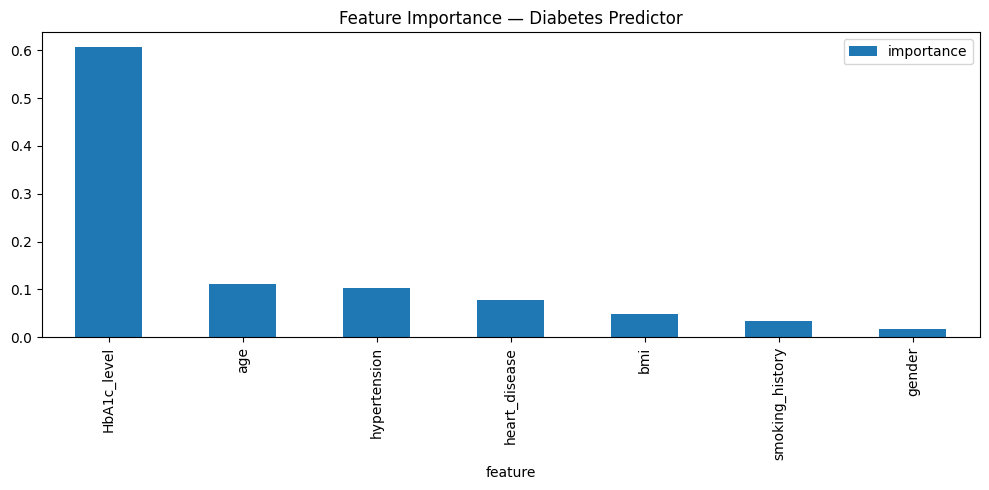


=== Predictions ===
Low diabetes risk. Probability: 0%
High diabetes risk. Probability: 100%
Please enter a valid age between 0 and 120
Invalid gender. Please enter one of: ['Female' 'Male' 'Other']


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# ── LOAD DATA ──────────────────────────────────────────────
df1 = pd.read_csv('/content/diabetes_prediction_dataset.csv')

# ── ENCODE CATEGORICAL COLUMNS ─────────────────────────────
le1 = LabelEncoder()
df1['gender'] = le1.fit_transform(df1['gender'])

le2 = LabelEncoder()
df1['smoking_history'] = le2.fit_transform(df1['smoking_history'])

# Drop direct diagnostic marker — causes data leakage
df1 = df1.drop(columns=['blood_glucose_level'])

# ── DEFINE FEATURES AND TARGET ─────────────────────────────
X = df1.drop(columns='diabetes')
y = df1['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# ── INITIAL XGBOOST ────────────────────────────────────────
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    scale_pos_weight=3, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_prob >= 0.3).astype(int)

print("=== Initial XGBoost ===")
print(classification_report(y_test, y_pred_tuned))
print("AUC Score:", roc_auc_score(y_test, y_prob))

# ── CROSS VALIDATION ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')

print("\n=== Cross Validation ===")
print("CV AUC scores:", scores)
print("Mean AUC:", scores.mean())
print("Std:", scores.std())

# ── HYPERPARAMETER TUNING ──────────────────────────────────
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [3, 5]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("\n=== GridSearchCV ===")
print("Best parameters:", grid_search.best_params_)
print("Best AUC:", grid_search.best_score_)

# ── BEST MODEL ─────────────────────────────────────────────
best_xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss'
)

best_xgb.fit(X_train, y_train)

y_prob = best_xgb.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_prob >= 0.3).astype(int)

print("\n=== Best XGBoost ===")
print(classification_report(y_test, y_pred_tuned))
print("AUC:", roc_auc_score(y_test, y_prob))

# ── FEATURE IMPORTANCE ─────────────────────────────────────
importances = best_xgb.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

importance_df.plot(kind='bar', x='feature', y='importance', figsize=(10, 5))
plt.title('Feature Importance — Diabetes Predictor')
plt.tight_layout()
plt.show()

# ── PREDICTION FUNCTION ────────────────────────────────────
def predict_diabetes(gender, age, hypertension, heart_disease,
                     smoking_history, bmi, HbA1c_level):

    if age < 0 or age > 120:
        return "Please enter a valid age between 0 and 120"
    if bmi < 0 or bmi > 70:
        return "Please enter a valid BMI between 0 and 70"
    if gender not in le1.classes_:
        return f"Invalid gender. Please enter one of: {le1.classes_}"
    if smoking_history not in le2.classes_:
        return f"Invalid smoking history. Please enter one of: {le2.classes_}"

    gender_encoded = le1.transform([gender])[0]
    smoking_encoded = le2.transform([smoking_history])[0]

    data = pd.DataFrame([[gender_encoded, age, hypertension, heart_disease,
                          smoking_encoded, bmi, HbA1c_level]],
                   columns=['gender', 'age', 'hypertension', 'heart_disease',
                            'smoking_history', 'bmi', 'HbA1c_level'])

    probability = best_xgb.predict_proba(data)[0][1]
    prediction = 1 if probability >= 0.3 else 0

    if prediction == 1:
        return f"High diabetes risk. Probability: {probability:.0%}"
    else:
        return f"Low diabetes risk. Probability: {probability:.0%}"

# ── TEST ───────────────────────────────────────────────────
print("\n=== Predictions ===")
print(predict_diabetes('Female', 90, 0, 0, 'never', 22.0, 5.5))
print(predict_diabetes('Male', 60, 1, 1, 'current', 35.0, 8.5))
print(predict_diabetes('Female', -5, 0, 0, 'never', 22.0, 5.5))
print(predict_diabetes('Unknown', 45, 0, 0, 'never', 22.0, 5.5))

HEART DISEASE MODEL


=== Initial XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        53
           1       0.78      0.83      0.80        46

    accuracy                           0.81        99
   macro avg       0.81      0.81      0.81        99
weighted avg       0.81      0.81      0.81        99

AUC: 0.8863822805578343

=== Cross Validation ===
CV AUC scores: [0.91294643 0.88616071 0.83928571 0.91294643 0.87731481]
Mean AUC: 0.88573082010582
Std: 0.027237990002977736

=== GridSearchCV ===
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 5}
Best AUC: 0.878011316169211

=== Best XGBoost ===
              precision    recall  f1-score   support

           0       0.91      0.58      0.71        53
           1       0.66      0.93      0.77        46

    accuracy                           0.75        99
   macro avg       0.79      0.76      0.74        99
weighted avg       0.80      

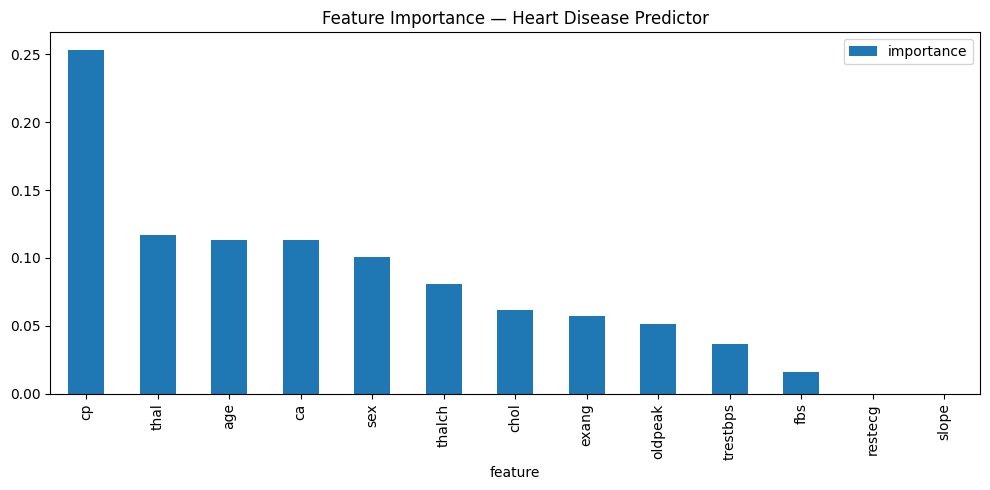


=== Predictions ===
High heart disease risk. Probability: 82%
Low heart disease risk. Probability: 12%
Please enter a valid age between 0 and 120


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# ── LOAD DATA ──────────────────────────────────────────────
df2 = pd.read_csv('/content/heart_disease_uci.csv')

# ── CLEAN DATA ─────────────────────────────────────────────
# Drop useless columns
df2 = df2.drop(columns=['id', 'dataset'])

# Drop nulls in key columns
df2 = df2.dropna(subset=['fbs', 'restecg', 'exang', 'slope', 'thal',
                          'ca', 'trestbps', 'chol', 'thalch', 'oldpeak'])
df2 = df2.reset_index(drop=True)

# Binarize target — 0 = no disease, 1 = has disease
df2['num'] = (df2['num'] > 0).astype(int)

# ── ENCODE CATEGORICAL COLUMNS ─────────────────────────────
le_sex = LabelEncoder()
le_cp = LabelEncoder()
le_fbs = LabelEncoder()
le_restecg = LabelEncoder()
le_exang = LabelEncoder()
le_slope = LabelEncoder()
le_thal = LabelEncoder()

df2['sex'] = le_sex.fit_transform(df2['sex'])
df2['cp'] = le_cp.fit_transform(df2['cp'])
df2['fbs'] = le_fbs.fit_transform(df2['fbs'])
df2['restecg'] = le_restecg.fit_transform(df2['restecg'])
df2['exang'] = le_exang.fit_transform(df2['exang'])
df2['slope'] = le_slope.fit_transform(df2['slope'])
df2['thal'] = le_thal.fit_transform(df2['thal'])

# ── DEFINE FEATURES AND TARGET ─────────────────────────────
X1 = df2.drop(columns='num')
y1 = df2['num']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.33, random_state=42)

# ── INITIAL XGBOOST ────────────────────────────────────────
xgb_1 = XGBClassifier(n_estimators=100, random_state=42,
                       scale_pos_weight=3, eval_metric='logloss')
xgb_1.fit(X1_train, y1_train)

y1_prob = xgb_1.predict_proba(X1_test)[:, 1]
y1_pred_tuned = (y1_prob >= 0.48).astype(int)

print("=== Initial XGBoost ===")
print(classification_report(y1_test, y1_pred_tuned))
print("AUC:", roc_auc_score(y1_test, y1_prob))

# ── CROSS VALIDATION ───────────────────────────────────────
cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_1, X1, y1, cv=cv1, scoring='roc_auc')

print("\n=== Cross Validation ===")
print("CV AUC scores:", scores)
print("Mean AUC:", scores.mean())
print("Std:", scores.std())

# ── HYPERPARAMETER TUNING ──────────────────────────────────
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [3, 5]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)

grid_search.fit(X1_train, y1_train)
print("\n=== GridSearchCV ===")
print("Best parameters:", grid_search.best_params_)
print("Best AUC:", grid_search.best_score_)

# ── BEST MODEL ─────────────────────────────────────────────
best_xgb_heart = XGBClassifier(
    learning_rate=0.01,
    max_depth=3,
    n_estimators=200,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)

best_xgb_heart.fit(X1_train, y1_train)

y1_prob = best_xgb_heart.predict_proba(X1_test)[:, 1]
y1_pred_tuned = (y1_prob >= 0.48).astype(int)

print("\n=== Best XGBoost ===")
print(classification_report(y1_test, y1_pred_tuned))
print("AUC:", roc_auc_score(y1_test, y1_prob))

# ── FEATURE IMPORTANCE ─────────────────────────────────────
importances = best_xgb_heart.feature_importances_
features = X1.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

importance_df.plot(kind='bar', x='feature', y='importance', figsize=(10, 5))
plt.title('Feature Importance — Heart Disease Predictor')
plt.tight_layout()
plt.show()

# ── PREDICTION FUNCTION ────────────────────────────────────
def predict_heart(age, sex, cp, trestbps, chol, fbs, restecg,
                  thalch, exang, oldpeak, slope, ca, thal):

    if age < 0 or age > 120:
        return "Please enter a valid age between 0 and 120"
    if sex not in le_sex.classes_:
        return f"Invalid sex. Please enter one of: {list(le_sex.classes_)}"
    if cp not in le_cp.classes_:
        return f"Invalid cp. Please enter one of: {list(le_cp.classes_)}"
    if exang not in le_exang.classes_:
        return f"Invalid exang. Please enter one of: {list(le_exang.classes_)}"
    if slope not in le_slope.classes_:
        return f"Invalid slope. Please enter one of: {list(le_slope.classes_)}"
    if thal not in le_thal.classes_:
        return f"Invalid thal. Please enter one of: {list(le_thal.classes_)}"

    # Encode text inputs
    sex = le_sex.transform([sex])[0]
    cp = le_cp.transform([cp])[0]
    fbs = le_fbs.transform([fbs])[0]
    restecg = le_restecg.transform([restecg])[0]
    exang = le_exang.transform([exang])[0]
    slope = le_slope.transform([slope])[0]
    thal = le_thal.transform([thal])[0]

    data_2 = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg,
                             thalch, exang, oldpeak, slope, ca, thal]],
                   columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                            'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

    probability = best_xgb_heart.predict_proba(data_2)[0][1]
    prediction = 1 if probability >= 0.48 else 0

    if prediction == 1:
        return f"High heart disease risk. Probability: {probability:.0%}"
    else:
        return f"Low heart disease risk. Probability: {probability:.0%}"

# ── TEST ───────────────────────────────────────────────────
print("\n=== Predictions ===")
print(predict_heart(63, 'Male', 'asymptomatic', 145, 233, False,
                    'lv hypertrophy', 150, True, 2.3, 'downsloping', 0, 'fixed defect'))
print(predict_heart(35, 'Female', 'non-anginal', 120, 180, False,
                    'normal', 170, False, 0.0, 'upsloping', 0, 'normal'))
print(predict_heart(-5, 'Male', 'asymptomatic', 145, 233, False,
                    'lv hypertrophy', 150, True, 2.3, 'downsloping', 0, 'fixed defect'))